In [14]:
%load_ext autoreload
%autoreload 2
import os

import matplotlib.pyplot as plt
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm
import numpy as np
from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import sample_8gaussians, sample_moons, torch_wrapper

savedir = "models/2d"
os.makedirs(savedir, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def eight_normal_sample(n, dim=2, scale=5, var=0.1):
    m = torch.distributions.multivariate_normal.MultivariateNormal(
        torch.zeros(dim), math.sqrt(var) * torch.eye(dim)
    )
    centers = [
        (1, 0),
        (-1, 0),
        (0, 1),
        (0, -1),
        (1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
    ]
    centers = torch.tensor(centers) * scale
    noise = m.sample((n,))
    multi = torch.multinomial(torch.ones(8), n, replacement=True)
    data = []
    for i in range(n):
        data.append(centers[multi[i]] + noise[i])
    data = torch.stack(data)
    return data
    
def eight_normal_log_prob(x, dim=2, scale=5, var=0.1):
    centers = [
        (1, 0),
        (-1, 0),
        (0, 1),
        (0, -1),
        (1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
    ]
    centers = torch.tensor(centers) * scale
    
    # Compute per-component densities
    sigma2 = var
    normalization = -0.5 * dim * torch.log(2 * torch.tensor(np.pi) * sigma2)
    log_probs = []
    for center in centers:
        log_prob = normalization - torch.sum((x - center) ** 2, dim=-1) / (2 * sigma2)
        log_probs.append(log_prob)
    log_probs = torch.stack(log_probs, dim=-1)
    # Log-sum-exp trick for numerical stability
    max_log_prob, _ = torch.max(log_probs, dim=-1, keepdim=True)
    mixture_log_prob = max_log_prob + torch.log(torch.sum(torch.exp(log_probs - max_log_prob), dim=-1, keepdim=True)) - torch.log(torch.tensor(len(centers))).squeeze()
    return mixture_log_prob

class torch_wrapper(torch.nn.Module):
    """Wraps model to torchdyn compatible format."""

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, t, x, *args, **kwargs):
        return self.model(torch.cat([x, t.repeat(x.shape[0])[:, None]], 1))


def exact_div_fn(u):
    """Accepts a function u:R^D -> R^D."""
    J = torch.func.jacrev(u)
    return lambda x, *args: torch.trace(J(x))


def div_fn_hutch_trace(u):
    def div_fn(x, eps):
        _, vjpfunc = torch.func.vjp(u, x)
        return (vjpfunc(eps)[0] * eps).sum()

    return div_fn


class cnf_wrapper(torch.nn.Module):
    """Wraps model to a torchdyn compatible CNF format.
    Appends an additional dimension representing the change in likelihood
    over time.
    """

    def __init__(self, model, likelihood_estimator="exact"):
        super().__init__()
        self.model = model
        self.div_fn, self.eps_fn = self.get_div_and_eps(likelihood_estimator)

    def get_div_and_eps(self, likelihood_estimator):
        if likelihood_estimator == "exact":
            return exact_div_fn, None
        if likelihood_estimator == "hutch_gaussian":
            return div_fn_hutch_trace, torch.randn_like
        if likelihood_estimator == "hutch_rademacher":

            def eps_fn(x):
                return torch.randint_like(x, low=0, high=2).float() * 2 - 1.0

            return div_fn_hutch_trace, eps_fn
        raise NotImplementedError(
            f"likelihood estimator {likelihood_estimator} is not implemented"
        )

    def forward(self, t, x, *args, **kwargs):
        t = t.squeeze()
        x = x[..., :-1]

        def vecfield(y):
            return self.model(torch.cat([y, t[None]]))

        if self.eps_fn is None:
            div = torch.vmap(self.div_fn(vecfield))(x)
        else:
            div = torch.vmap(self.div_fn(vecfield))(x, self.eps_fn(x))
        dx = self.model(torch.cat([x, t.repeat(x.shape[0])[:, None]], 1))
        return torch.cat([dx, div[:, None]], dim=-1)

In [3]:
def plot_trajectories_sb(traj, legend=True):
    n = 2000
    plt.figure(figsize=(10, 10))
    plt.scatter(traj[0, :n, 0], traj[0, :n, 1], s=10, alpha=0.8, c="black")
    plt.scatter(traj[:, :n, 0], traj[:, :n, 1], s=0.4, alpha=0.1, c="olive")
    plt.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=4, alpha=1, c="blue")

    for i in range(5, 15):
        plt.plot(traj[:, i, 0], traj[:, i, 1], alpha=0.9, c="red")
    if legend:
        plt.legend([r"$p_0$", r"$p_t$", r"$p_1$", r"$X_t \mid X_0$"])
    plt.xticks([])
    plt.yticks([])
    plt.axis("off")

In [4]:
class EnergyModel(torch.nn.Module):
    def __init__(self, v):
        super().__init__()
        self.v = v
    def forward(self, x):
        t = x[:, -1]
        #one_over_two_sigma_t_squared = torch.clip(t / torch.clip(4 * (1 - t), min=1e-2), min=1e-2, max=1e-2)
        return ((self.v(x) - x[:, :-1]) ** 2).sum(-1)
class GradModel(torch.nn.Module):
    def __init__(self, action):
        super().__init__()
        self.action = action

    def forward(self, x):
        with torch.enable_grad():
            x = x.requires_grad_(True)
            grad = torch.autograd.grad(torch.sum(self.action(x)), x, create_graph=True)[0]
            return grad[:, :-1]

class MLP2(torch.nn.Module):
    def __init__(self, dim, out_dim=None, w=64, time_varying=False):
        super().__init__()
        self.time_varying = time_varying
        if out_dim is None:
            out_dim = dim
        self.net = torch.nn.Sequential(
            torch.nn.Linear(dim + (1 if time_varying else 0), w),
            torch.nn.ReLU(),
            torch.nn.Linear(w, w),
            torch.nn.SiLU(),
            torch.nn.Linear(w, w),
            torch.nn.SiLU(),
            torch.nn.Linear(w, out_dim),
        )

    def forward(self, x):
        return self.net(x)

In [5]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
device = "cpu"
batch_size = 256
sigma = 0
dim = 2
model = MLP(dim=dim, time_varying=True, w=64)
#energy_model = EnergyModel(flow_model)
#model = GradModel(energy_model)
#action = MLP2(dim=dim, out_dim=1, time_varying=True, w=256)
#model = GradModel(action)
#score_model = MLP(dim=dim, time_varying=True, w=64)
optimizer = torch.optim.Adam(model.parameters(), 0.01)
FM = ConditionalFlowMatcher(sigma=sigma)
# FM = SchrodingerBridgeConditionalFlowMatcher(sigma=sigma)
eps = 1e-2

In [91]:
for i in tqdm(range(30000)):
    optimizer.zero_grad()
    x0 = torch.randn(batch_size,2)
    x1 = sample_8gaussians(batch_size)
    t, xt, ut, _ = FM.sample_location_and_conditional_flow(x0, x1, return_noise=True)
    vt = model(torch.cat([xt, t[:, None]], dim=-1))
    #vt = (xt + (1 - t[:,None]) * score_t) / torch.clip(t[:,None], min=eps)
    #true_score_t = (t[:,None] * ut - xt) / torch.clip(1 - t[:,None], min=eps)
    #pred_score_t = (t[:,None] * vt - xt) / torch.clip(1 - t[:,None], min=eps)
    flow_loss = torch.mean((vt - ut) ** 2)
    loss = flow_loss
    loss.backward()
    optimizer.step()

100%|███████████████████████████████████████████████████████████████████████████████████████| 30000/30000 [01:40<00:00, 299.46it/s]


In [41]:
#def vt(x):
#    return torch.zeros_like(x)[..., :-1]

In [6]:
model = torch.load(f"{savedir}/vector_flow_v3.pt")

/tmp/ipykernel_4167429/924668035.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(f"{savedir}/vector_flow_v3.pt")


In [7]:
# torch.save(model, f"{savedir}/vector_flow_v3.pt")

In [8]:
node = NeuralODE(torch_wrapper(model), solver="euler", sensitivity="adjoint", atol=1e-4, rtol=1e-4)
x0 = torch.randn(1024,2)

with torch.no_grad():
    traj = node.trajectory(
        x0,
        t_span=torch.linspace(0, 1, 100, device=device),
    )

/network/scratch/a/alexander.tong/micromamba/envs/tbg2/lib/python3.10/site-packages/torchdyn/numerics/odeint.py:83: UserWarning: Setting tolerances has no effect on fixed-step methods
  warn("Setting tolerances has no effect on fixed-step methods")


In [9]:
from torch.distributions import MultivariateNormal

prior = MultivariateNormal(torch.zeros(dim, device=device), torch.eye(dim, device=device))


In [10]:
# a = t
# b = 1-t
# a_dot = 1
# b_dot = -1
# kappa = 1 / t
# eta = (1 - t) * (1 / t (1 - t) - -1)
# eta = (1 - t) * ( 1 - t + t) / t
# eta = (1 - t) / t

# sigma_t = 0.1

In [11]:
n_steps = 1000
min_t = 0.1
dt = (1- min_t) / n_steps
x0 = torch.randn(1024,2)
traj_sde = [x0]
xt = x0
eps = 1e-1
logp = prior.log_prob(x0)
logps = [logp]
components = []

with torch.no_grad():
    for t in torch.linspace(min_t, 1 - dt, n_steps):
        #sigma_t_squared = 0.1
        # sigma_t = (2 (1 - t) / t) ** 0.5
        #sigma_t = sigma_t_squared ** 0.5
        sigma_t_squared = (2 * (1 - t) / torch.clip(t, min=eps))
        sigma_t_squared = 2 * (1 - t) / torch.clip(t, min=0.1)
        # sigma_t = (2 (1 - t) / t) ** 0.5
        sigma_t = sigma_t_squared ** 0.5
        vt = model(torch.cat([xt, t.repeat(1024, 1)], dim=-1))
        # st is correct we checked
        st = vt + sigma_t_squared * (t * vt - xt) / torch.clip(1-t, min=eps) / 2
        eps_t = torch.randn_like(xt)
        noise_t = sigma_t * eps_t * (dt ** 0.5)
        dxt = st * dt + noise_t
        
        score_t = (t * vt - xt) / torch.clip(1 - t, min=eps)
        a = -xt.shape[-1] / torch.clip(t, min=eps) * dt * torch.ones(xt.shape[0])
        b = (sigma_t_squared / 2 * score_t * score_t).sum(-1) * dt
        c = (score_t * noise_t).sum(-1)
        dlogp = a + b + c
        logp = logp + dlogp
        logps.append(logp)
        components.append(torch.stack([a, b, c]))
        traj_sde.append(xt)
        xt = xt + dxt
traj_sde = torch.stack(traj_sde)

cnf = NeuralODE(
    cnf_wrapper(model, likelihood_estimator="exact"), 
    atol=1e-3,
    rtol=1e-3,
    solver="dopri5", sensitivity="adjoint"
)

x1 = traj_sde[-1]
device = "cpu"
steps = n_steps
with torch.no_grad():
    x1_with_ll = torch.cat([x1, torch.zeros(x1.shape[0], 1, device=device)], dim=-1)
    cnf_ll_traj = cnf.trajectory(x1_with_ll, t_span=torch.linspace(1, 0, steps + 1, device=device))
    x0_with_ll = cnf_ll_traj[-1]
    cnf_x0 = x0_with_ll[..., :-1]
    cnf_logprob = prior.log_prob(x0_with_ll[..., :-1]) + x0_with_ll[..., -1]

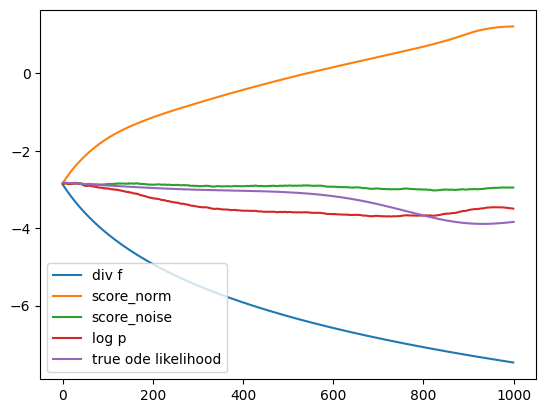

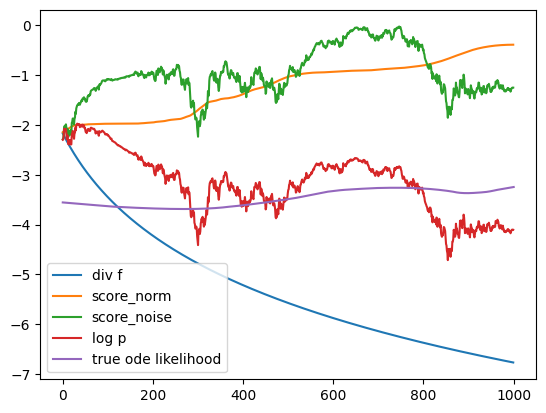

In [12]:

for i in range(0,3):
    plot = plt.plot((prior.log_prob(x0)[None] + torch.cumsum(torch.stack(components)[:, i], dim=0)).mean(-1), label=["div f", "score_norm", "score_noise"][i])
plt.plot((prior.log_prob(x0)[None] + torch.cumsum(torch.stack(components)[:, :].sum(-2), dim=0)).mean(-1), label="log p")
plt.plot((cnf_ll_traj[:, :, -1] + prior.log_prob(x0_with_ll[:, :-1])).mean(-1), label="true ode likelihood")
m = 1
plt.legend()
plt.show()
for i in range(0,3):
    plot = plt.plot(prior.log_prob(x0)[None, :m] + torch.cumsum(torch.stack(components)[:, i, :m], dim=0), label=["div f", "score_norm", "score_noise"][i])
plt.plot(prior.log_prob(x0)[None, :m] + torch.cumsum(torch.stack(components)[:, :, :m].sum(-2), dim=0), label="log p")
plt.plot(cnf_ll_traj[:, :m, -1] + prior.log_prob(x0_with_ll[:m, :-1]), label="true ode likelihood")
plt.legend()
plt.show()

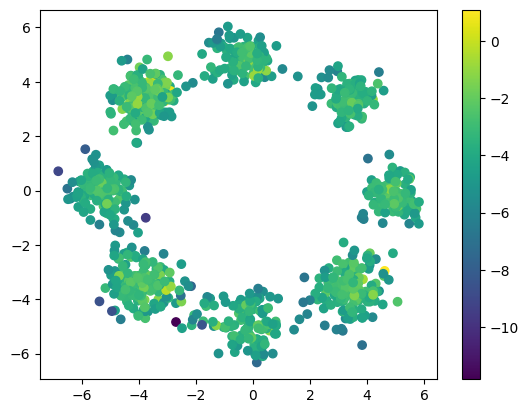

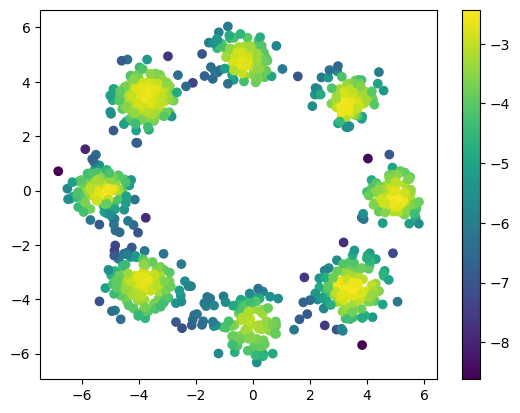

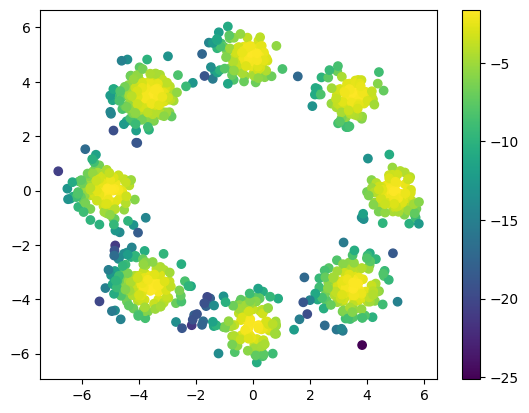

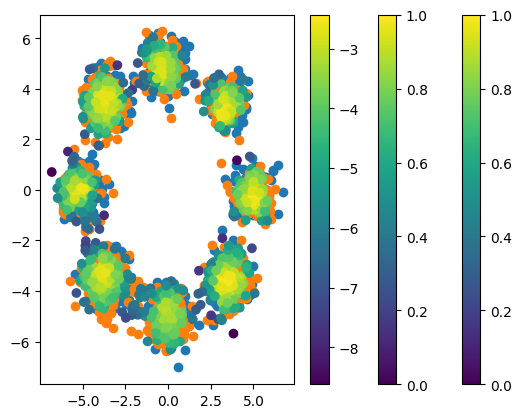

In [15]:
scatter = plt.scatter(traj_sde[-1][:,0].detach(), traj_sde[-1][:,1].detach(), c=logp.detach())
plt.colorbar(scatter)
plt.show()
scatter = plt.scatter(traj_sde[-1][:,0].detach(), traj_sde[-1][:,1].detach(), c=cnf_logprob.detach())
plt.colorbar(scatter)
plt.show()
true_logprob = eight_normal_log_prob(traj_sde[-1])
scatter = plt.scatter(traj_sde[-1][:,0].detach(), traj_sde[-1][:,1].detach(), c=true_logprob.detach())
plt.colorbar(scatter)
plt.show()
x1 = sample_8gaussians(1024)
scatter = plt.scatter(x1[:,0].detach(), x1[:,1].detach())
plt.colorbar(scatter)
scatter = plt.scatter(traj[-1][:,0].detach(), traj[-1][:,1].detach())
plt.colorbar(scatter)
scatter = plt.scatter(traj_sde[-1][:,0].detach(), traj_sde[-1][:,1].detach(), c=cnf_logprob.detach())
plt.colorbar(scatter)


In [17]:
import numpy as np
import pandas as pd

df = pd.DataFrame([logp.detach().numpy(), cnf_logprob.detach().numpy(), true_logprob.detach().numpy()], index = ["Ito", "CNF", "True"])
df.T.corr(method="spearman")

,Ito,CNF,True
Ito,1.000000,0.652625,0.576217
CNF,0.652625,1.000000,0.842710
True,0.576217,0.842710,1.000000


In [18]:
df.T.corr(method="pearson")

,Ito,CNF,True
Ito,1.000000,0.656954,0.588258
CNF,0.656954,1.000000,0.890251
True,0.588258,0.890251,1.000000


torch.Size([1024, 2])


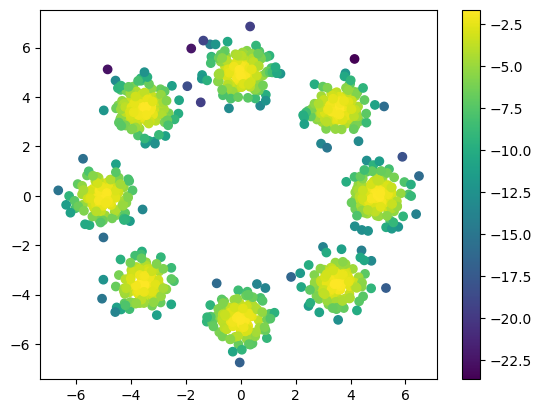

In [19]:
x1 = eight_normal_sample(1024, 2)
logprob_x1 = eight_normal_log_prob(x1, 2)
scatter = plt.scatter(x1[:,0], x1[:,1], c=logprob_x1)
plt.colorbar(scatter)
logprob_x1.shape
print(x1.shape)

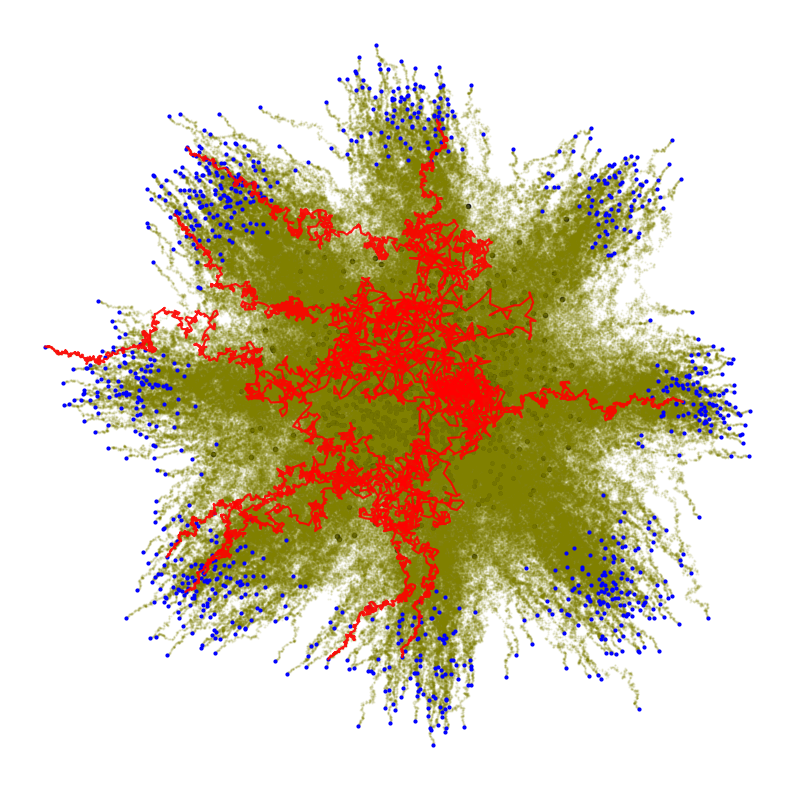

In [20]:
plot_trajectories_sb(traj_sde.detach().cpu().numpy(), legend=False)


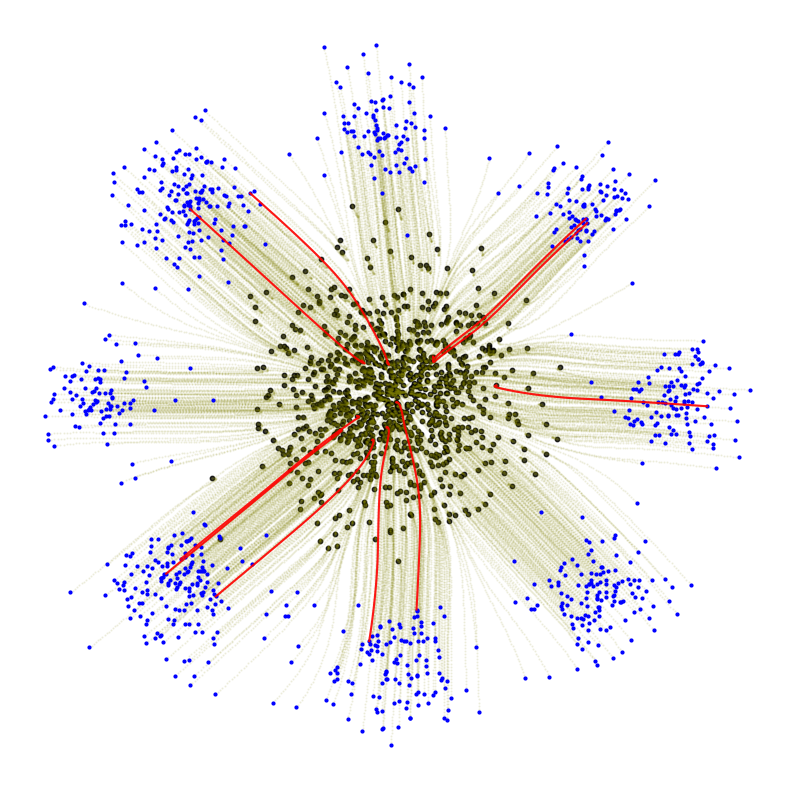

In [21]:
plot_trajectories_sb(traj.detach().cpu().numpy(), legend=False)
